# Feature Engineering

In [5]:
# Import required libraries
import pandas as pd
import numpy as np


# Load the cleaned dataset generated in the preprocessing step
# This ensures we start from a fully cleaned and consistent dataset
df = pd.read_csv("weather_data_preprocessed.csv")


# Convert DATE column back to datetime format
# When reading from CSV, pandas treats it as a string by default
df["DATE"] = pd.to_datetime(df["DATE"])


# Set DATE as index for time series feature creation
df = df.set_index("DATE")


# Preview dataset structure before creating new features
print("Initial dataset shape:", df.shape)
df.head()

Initial dataset shape: (5844, 30)


,AWND,PRCP,SNOW,SNWD,TMAX,TMIN,WDF2,WDF5,WESD,WSF2,...,WT11,WT13,WT14,WT15,WT16,WT17,WT18,WT19,WT21,WT22
DATE,,,,,,,,,,,,,,,,,,,,,
2010-01-01,5.37,0.04,0.0,0.0,41.0,32,320.0,320.0,0.0,19.9,...,0,1,0,0,1,0,1,0,0,0
2010-01-02,23.71,0.00,0.1,0.0,33.0,17,300.0,300.0,0.0,34.9,...,0,0,0,0,1,0,1,0,0,0
2010-01-03,25.50,0.00,0.0,0.0,24.0,18,310.0,320.0,0.0,40.9,...,0,0,0,0,1,0,1,0,0,0
2010-01-04,17.67,0.00,0.0,0.0,32.0,20,310.0,310.0,0.0,23.9,...,0,0,0,0,0,0,0,0,0,0
2010-01-05,15.88,0.00,0.0,0.0,32.0,21,310.0,310.0,0.0,21.0,...,0,0,0,0,0,0,0,0,0,0


1. Time Based Features (Seasonality)

In [6]:
# Extract basic calendar features from the date index

df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day

# Day of year captures the position within the annual weather cycle
df["day_of_year"] = df.index.dayofyear

# Week number can capture medium-term seasonal patterns
df["week_of_year"] = df.index.isocalendar().week

2. Cyclical Encoding for Seasonal Patterns

In [7]:
# Convert day_of_year into cyclical features
# This allows models to capture smooth seasonal transitions

df["sin_day_of_year"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["cos_day_of_year"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

3. Lag Features

In [8]:
# Define lag intervals
# These represent past observations used as predictors

lags = [1, 3, 7, 14]


# Create lag features for both TMAX and TMIN
# Example: TMAX_lag_1 represents yesterday's maximum temperature

for lag in lags:

    df[f"TMAX_lag_{lag}"] = df["TMAX"].shift(lag)
    df[f"TMIN_lag_{lag}"] = df["TMIN"].shift(lag)

4. Rolling Window Features (Trend Detection)

In [9]:
# Rolling mean captures local weather trends

df["TMAX_roll7_mean"] = df["TMAX"].rolling(window=7).mean()
df["TMIN_roll7_mean"] = df["TMIN"].rolling(window=7).mean()


# 30-day rolling window helps capture longer seasonal changes

df["TMAX_roll30_mean"] = df["TMAX"].rolling(window=30).mean()
df["TMIN_roll30_mean"] = df["TMIN"].rolling(window=30).mean()

5. Rolling Standard Deviation (Temperature Variability)

In [10]:
df["TMAX_roll7_std"] = df["TMAX"].rolling(window=7).std()
df["TMIN_roll7_std"] = df["TMIN"].rolling(window=7).std()

Handle Missing Values Created by Lag/Rolling Operations

In [11]:
df = df.dropna()

Final dataset check and saving feature engineered dataset

In [12]:
print("Dataset shape after feature engineering:", df.shape)

print("Remaining missing values:", df.isna().sum().sum())

df.head()

Dataset shape after feature engineering: (5815, 51)
Remaining missing values: 0


,AWND,PRCP,SNOW,SNWD,TMAX,TMIN,WDF2,WDF5,WESD,WSF2,...,TMAX_lag_7,TMIN_lag_7,TMAX_lag_14,TMIN_lag_14,TMAX_roll7_mean,TMIN_roll7_mean,TMAX_roll30_mean,TMIN_roll30_mean,TMAX_roll7_std,TMIN_roll7_std
DATE,,,,,,,,,,,,,,,,,,,,,
2010-01-30,14.32,0.00,0.0,0.0,20.0,14,330.0,330.0,0.0,25.1,...,42.0,26.0,49.0,33.0,39.857143,26.714286,38.900000,26.000000,12.495714,11.071198
2010-01-31,13.20,0.00,0.0,0.0,30.0,15,20.0,360.0,0.0,21.0,...,49.0,27.0,42.0,31.0,37.142857,25.000000,38.533333,25.433333,12.239670,11.916375
2010-02-01,13.87,0.00,0.0,0.0,37.0,25,250.0,280.0,0.0,21.0,...,53.0,45.0,50.0,36.0,34.857143,22.142857,38.666667,25.700000,10.090071,8.112307
2010-02-02,6.26,0.00,0.0,0.0,33.0,25,270.0,270.0,0.0,14.1,...,47.0,35.0,46.0,33.0,32.857143,20.714286,38.966667,25.933333,8.552360,6.102302
2010-02-03,9.84,0.03,0.5,1.0,40.0,28,310.0,310.0,0.0,28.0,...,42.0,30.0,44.0,33.0,32.571429,20.428571,39.233333,26.200000,8.223080,5.623082


In [13]:
df.to_csv("weather_data_features.csv")

print("Feature engineering completed successfully.")

Feature engineering completed successfully.


# Model Training and Evaluation


In [14]:
# Import necessary libraries
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
# Load dataset produced in feature engineering stage

df = pd.read_csv("weather_data_features.csv")

df["DATE"] = pd.to_datetime(df["DATE"])

df = df.set_index("DATE")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (5815, 51)


,AWND,PRCP,SNOW,SNWD,TMAX,TMIN,WDF2,WDF5,WESD,WSF2,...,TMAX_lag_7,TMIN_lag_7,TMAX_lag_14,TMIN_lag_14,TMAX_roll7_mean,TMIN_roll7_mean,TMAX_roll30_mean,TMIN_roll30_mean,TMAX_roll7_std,TMIN_roll7_std
DATE,,,,,,,,,,,,,,,,,,,,,
2010-01-30,14.32,0.00,0.0,0.0,20.0,14,330.0,330.0,0.0,25.1,...,42.0,26.0,49.0,33.0,39.857143,26.714286,38.900000,26.000000,12.495714,11.071198
2010-01-31,13.20,0.00,0.0,0.0,30.0,15,20.0,360.0,0.0,21.0,...,49.0,27.0,42.0,31.0,37.142857,25.000000,38.533333,25.433333,12.239670,11.916375
2010-02-01,13.87,0.00,0.0,0.0,37.0,25,250.0,280.0,0.0,21.0,...,53.0,45.0,50.0,36.0,34.857143,22.142857,38.666667,25.700000,10.090071,8.112307
2010-02-02,6.26,0.00,0.0,0.0,33.0,25,270.0,270.0,0.0,14.1,...,47.0,35.0,46.0,33.0,32.857143,20.714286,38.966667,25.933333,8.552360,6.102302
2010-02-03,9.84,0.03,0.5,1.0,40.0,28,310.0,310.0,0.0,28.0,...,42.0,30.0,44.0,33.0,32.571429,20.428571,39.233333,26.200000,8.223080,5.623082


Define features and targets

In [16]:
target_columns = ["TMAX","TMIN"]

X = df.drop(columns=target_columns)

y = df[target_columns]

Train-Test Split

In [17]:
train_size = int(len(df)*0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4652
Testing samples: 1163


Walk Forward Prediction Function


In [18]:
def walk_forward_validation(model, X_train, y_train, X_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    return predictions

Define models- ridge regression, random forest and xgboost

In [19]:
ridge_model = Ridge()

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

models = {
    "Ridge Regression": ridge_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

Train the models with walk forward validation and calculate evaluation metrics

In [20]:
results = []

predictions_dict = {}

for name, model in models.items():

    print("Training:", name)

    preds = walk_forward_validation(
        model,
        X_train,
        y_train,
        X_test
    )

    predictions_dict[name] = preds

    mae = mean_absolute_error(y_test, preds)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

Training: Ridge Regression
Training: Random Forest
Training: XGBoost


# Model Comparison

              Model       MAE      RMSE  R2 Score
2           XGBoost  3.367047  4.355054  0.925490
1     Random Forest  3.563043  4.594242  0.916948
0  Ridge Regression  3.606254  4.617101  0.916340


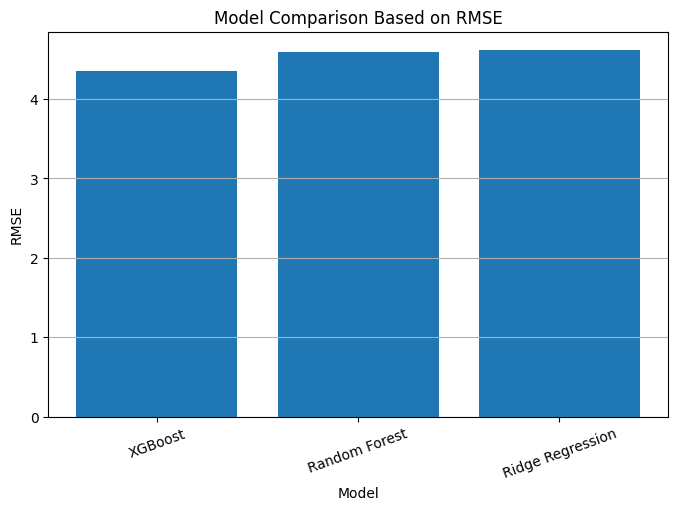

In [21]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="RMSE")

print(results_df)

# Model Comparison Chart
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Model Comparison Based on RMSE")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

# Analysis of Actual Values vs Predictions

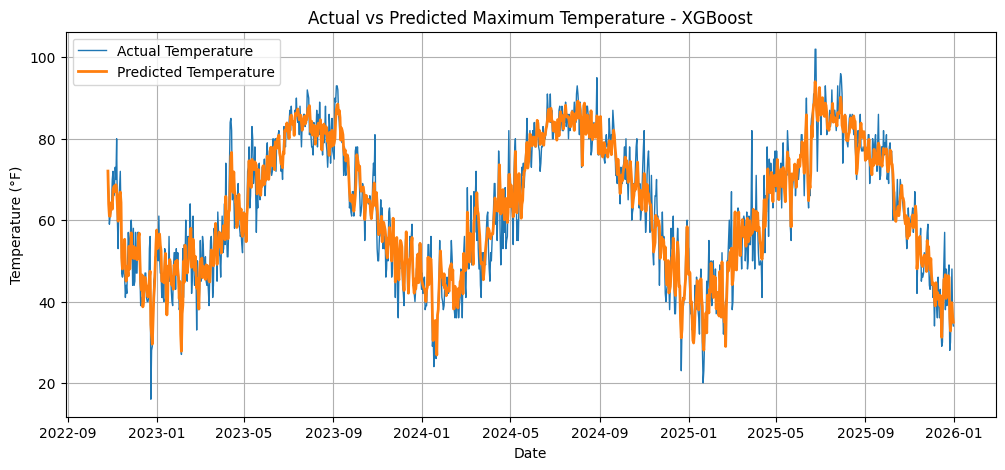

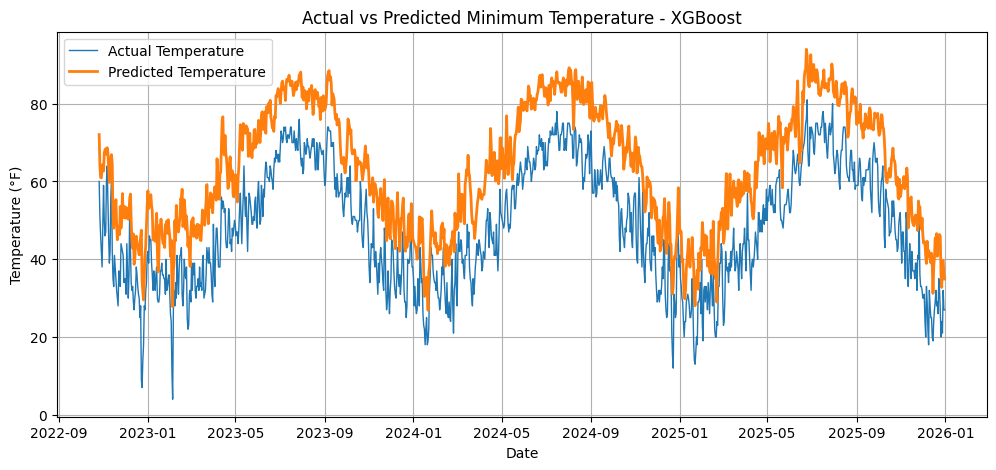

In [22]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test["TMAX"], label="Actual Temperature", linewidth=1)

plt.plot(y_test.index, preds[:,0], label="Predicted Temperature", linewidth=2)

plt.title("Actual vs Predicted Maximum Temperature - XGBoost")

plt.xlabel("Date")
plt.ylabel("Temperature (°F)")

plt.legend()

plt.grid(True)

plt.show()

plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test["TMIN"], label="Actual Temperature", linewidth=1)

plt.plot(y_test.index, preds[:,0], label="Predicted Temperature", linewidth=2)

plt.title("Actual vs Predicted Minimum Temperature - XGBoost")

plt.xlabel("Date")
plt.ylabel("Temperature (°F)")

plt.legend()

plt.grid(True)

plt.show()

# Model Selection

Train the best model on training data

In [23]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Performing Model:", best_model_name)

Best Performing Model: XGBoost


In [24]:
best_model = models[best_model_name]

In [25]:
best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
import joblib

joblib.dump(best_model, "best_weather_model.pkl")

print("Model saved successfully")

Model saved successfully


In [27]:
final_predictions = best_model.predict(X_test)

print("Prediction shape:", final_predictions.shape)

Prediction shape: (1163, 2)


In [28]:
forecast_df = pd.DataFrame({

    "Actual_TMAX": y_test["TMAX"],
    "Predicted_TMAX": final_predictions[:,0],

    "Actual_TMIN": y_test["TMIN"],
    "Predicted_TMIN": final_predictions[:,1]

}, index=y_test.index)

forecast_df.head(15)

,Actual_TMAX,Predicted_TMAX,Actual_TMIN,Predicted_TMIN
DATE,,,,
2022-10-26,71.0,72.057503,60,59.903042
2022-10-27,67.0,64.004318,51,47.880955
2022-10-28,59.0,61.042515,46,46.207077
2022-10-29,61.0,60.929634,42,44.342888
2022-10-30,62.0,63.439915,38,48.395031
2022-10-31,64.0,64.368568,49,49.226486
2022-11-01,70.0,62.683163,59,48.337429
2022-11-02,72.0,67.346725,50,49.786167
2022-11-03,66.0,68.157722,46,49.105003


# SHAP- Feature Importance Analysis

In [29]:
# Import Shap
import shap

In [30]:
# Create SHAP Explainer
explainer = shap.Explainer(best_model, X_train)

In [31]:
# Analyze the subset of test data and compute shap values
X_sample = X_test.sample(200, random_state=42)

shap_values = explainer(X_sample)

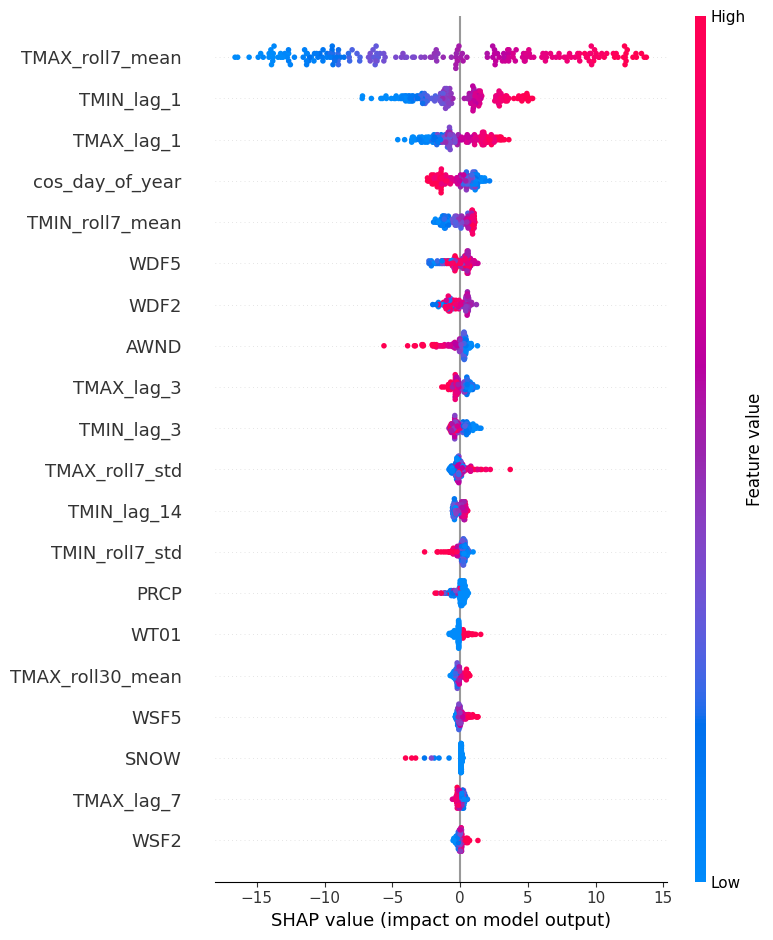

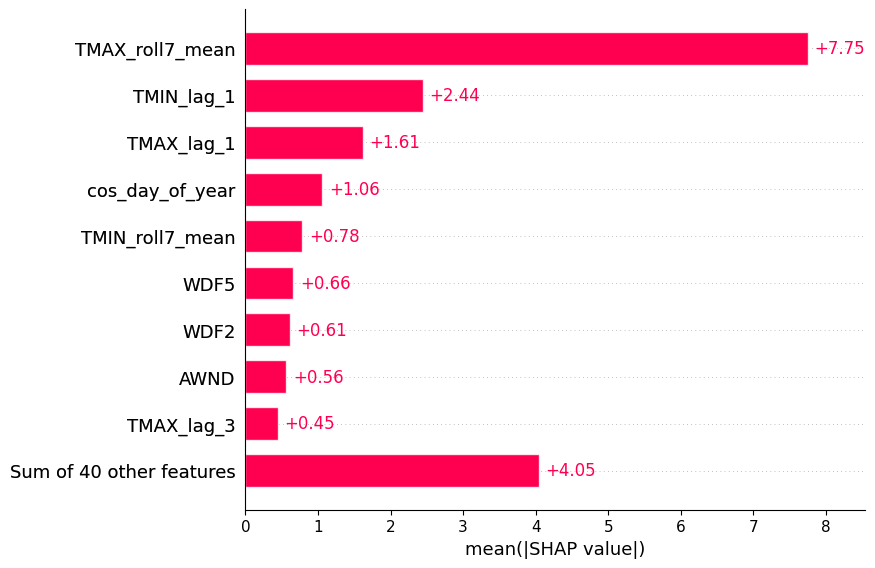

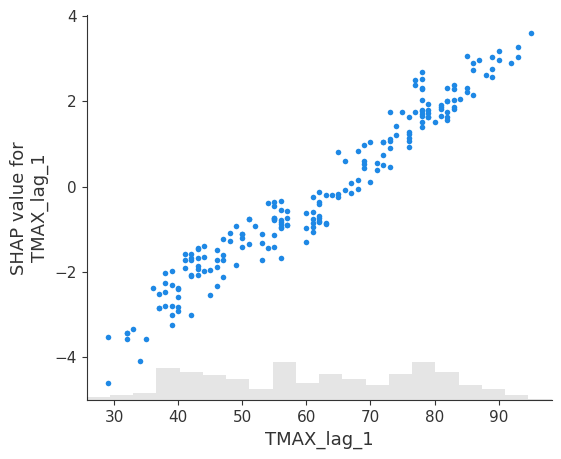

In [32]:
# SHAP for TMAX Prediction
shap.summary_plot(shap_values[:,:,0], X_sample)

# SHAP Feature Importance Bar Chart
shap.plots.bar(shap_values[:,:,0])

# SHAP Dependence Plot
shap.plots.scatter(shap_values[:,:,0][:,"TMAX_lag_1"])

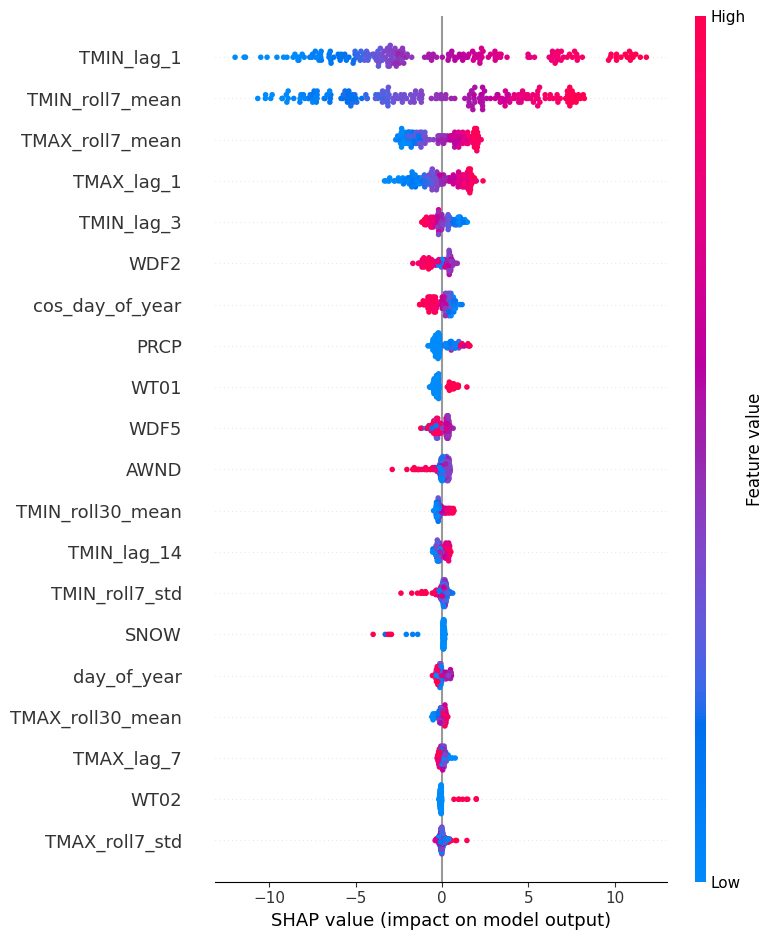

In [33]:
# SHAP for TMIN Prediction
shap.summary_plot(shap_values[:,:,1], X_sample)

# OpenWeatherMap API Integration and Forecasting

In [34]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from collections import defaultdict
from google.colab import userdata

# Load API Key

API_KEY = userdata.get("WEATHER_API_KEY")

if API_KEY is None:
    raise ValueError("Add WEATHER_API_KEY in Colab Secrets")

print("API key loaded successfully")

# City Input

city = input("Enter city name: ")

params = {
    "q": city,
    "appid": API_KEY,
    "units": "imperial"
}

# Feature Defination

WT_COLS = [
"WT01","WT02","WT03","WT04","WT05","WT06","WT07","WT08","WT09",
"WT11","WT13","WT14","WT15","WT16","WT17","WT18","WT19","WT21","WT22"
]

FEATURE_COLS = [
"AWND","PRCP","SNOW","SNWD","WDF2","WDF5","WESD","WSF2","WSF5",
*WT_COLS,
"year","month","day","day_of_year","week_of_year",
"sin_day_of_year","cos_day_of_year",
"TMAX_lag_1","TMIN_lag_1",
"TMAX_lag_3","TMIN_lag_3",
"TMAX_lag_7","TMIN_lag_7",
"TMAX_lag_14","TMIN_lag_14",
"TMAX_roll7_mean","TMIN_roll7_mean",
"TMAX_roll30_mean","TMIN_roll30_mean",
"TMAX_roll7_std","TMIN_roll7_std"
]

# Feaure Builder Function

def build_feature_row(target_date, weather_vars, tmax_hist, tmin_hist):

    doy = target_date.timetuple().tm_yday

    row = {
        "AWND": weather_vars.get("AWND",0),
        "PRCP": weather_vars.get("PRCP",0),
        "SNOW": weather_vars.get("SNOW",0),
        "SNWD":0,
        "WDF2":weather_vars.get("WDF2",0),
        "WDF5":weather_vars.get("WDF5",0),
        "WESD":0,
        "WSF2":weather_vars.get("WSF2",0),
        "WSF5":weather_vars.get("WSF5",0),

        **{c:0 for c in WT_COLS},

        "year":target_date.year,
        "month":target_date.month,
        "day":target_date.day,
        "day_of_year":doy,
        "week_of_year":target_date.isocalendar()[1],

        "sin_day_of_year":np.sin(2*np.pi*doy/365),
        "cos_day_of_year":np.cos(2*np.pi*doy/365),

        "TMAX_lag_1":tmax_hist[-1],
        "TMIN_lag_1":tmin_hist[-1],

        "TMAX_lag_3":tmax_hist[-3],
        "TMIN_lag_3":tmin_hist[-3],

        "TMAX_lag_7":tmax_hist[-7],
        "TMIN_lag_7":tmin_hist[-7],

        "TMAX_lag_14":tmax_hist[-14],
        "TMIN_lag_14":tmin_hist[-14],

        "TMAX_roll7_mean":np.mean(tmax_hist[-7:]),
        "TMIN_roll7_mean":np.mean(tmin_hist[-7:]),

        "TMAX_roll30_mean":np.mean(tmax_hist[-30:]),
        "TMIN_roll30_mean":np.mean(tmin_hist[-30:]),

        "TMAX_roll7_std":np.std(tmax_hist[-7:]),
        "TMIN_roll7_std":np.std(tmin_hist[-7:])
    }

    return pd.DataFrame([row])[FEATURE_COLS]

# Current Weather API

current_url = "https://api.openweathermap.org/data/2.5/weather"

response = requests.get(current_url, params=params)
data = response.json()

wind = data.get("wind",{})

current_temp = data["main"]["temp"]
current_min = data["main"]["temp_min"]
current_max = data["main"]["temp_max"]

current_desc = data["weather"][0]["description"].title()
current_humidity = data["main"]["humidity"]
current_wind = wind.get("speed",0)

weather_vars_today = {
"AWND":current_wind,
"PRCP":data.get("rain",{}).get("1h",0),
"SNOW":data.get("snow",{}).get("1h",0),
"WDF2":wind.get("deg",0),
"WDF5":wind.get("deg",0),
"WSF2":current_wind,
"WSF5":current_wind
}

# Temperature History

tmax_history = list(df["TMAX"].tail(30))
tmin_history = list(df["TMIN"].tail(30))

tmax_history[-1] = current_max
tmin_history[-1] = current_min

# Today's ML Prediction

now = datetime.now()

today_features = build_feature_row(now,weather_vars_today,tmax_history,tmin_history)

prediction = best_model.predict(today_features)

pred_tmax = 0.6*prediction[0][0] + 0.4*current_max
pred_tmin = 0.6*prediction[0][1] + 0.4*current_min

print("\nWEATHER REPORT |",city.upper(),"|",now.strftime("%d %B %Y"))

print("Current Temp:",round(current_temp,1),"F")

print("Predicted TMAX:",round(pred_tmax,1),"F")
print("Predicted TMIN:",round(pred_tmin,1),"F")

# Forest API

forecast_url="https://api.openweathermap.org/data/2.5/forecast"

forecast_response=requests.get(forecast_url,params=params)

forecast_data=forecast_response.json()

daily_data=defaultdict(list)

for item in forecast_data["list"]:

    date=datetime.fromtimestamp(item["dt"]).date()
    daily_data[date].append(item)

# Forecast Loop

rolling_tmax=tmax_history.copy()
rolling_tmin=tmin_history.copy()

rolling_tmax.append(pred_tmax)
rolling_tmin.append(pred_tmin)

today_date=now.date()

forecast_results=[]

print("\n5 DAY FORECAST")

for date,entries in list(daily_data.items())[1:6]:

    api_tmax=max(e["main"]["temp_max"] for e in entries)
    api_tmin=min(e["main"]["temp_min"] for e in entries)

    wind_speeds=[e["wind"]["speed"] for e in entries]

    weather_vars={
        "AWND":np.mean(wind_speeds),
        "PRCP":sum(e.get("rain",{}).get("3h",0) for e in entries),
        "SNOW":sum(e.get("snow",{}).get("3h",0) for e in entries),
        "WDF2":np.mean([e["wind"].get("deg",0) for e in entries]),
        "WDF5":np.mean([e["wind"].get("deg",0) for e in entries]),
        "WSF2":np.mean(wind_speeds),
        "WSF5":np.mean(wind_speeds)
    }

    target_dt=datetime.combine(date,datetime.min.time())

    features=build_feature_row(target_dt,weather_vars,rolling_tmax,rolling_tmin)

    pred=best_model.predict(features)

    ml_tmax=0.6*pred[0][0]+0.4*api_tmax
    ml_tmin=0.6*pred[0][1]+0.4*api_tmin

    print(date, "| MAX:",round(ml_tmax,1),"F | MIN:",round(ml_tmin,1),"F")

    forecast_results.append((date,ml_tmax,ml_tmin))

    rolling_tmax.append(ml_tmax)
    rolling_tmin.append(ml_tmin)

# Save forecasting output csv file

forecast_df=pd.DataFrame(forecast_results,columns=["Date","TMAX","TMIN"])

forecast_df.to_csv("forecast_output.csv",index=False)

print("\nForecast saved to forecast_output.csv")

API key loaded successfully
Enter city name: New York

WEATHER REPORT | NEW YORK | 16 March 2026
Current Temp: 60.2 F
Predicted TMAX: 58.7 F
Predicted TMIN: 50.3 F

5 DAY FORECAST
2026-03-17 | MAX: 56.6 F | MIN: 38.8 F
2026-03-18 | MAX: 44.7 F | MIN: 34.1 F
2026-03-19 | MAX: 45.0 F | MIN: 32.6 F
2026-03-20 | MAX: 49.0 F | MIN: 37.6 F
2026-03-21 | MAX: 53.4 F | MIN: 42.3 F

Forecast saved to forecast_output.csv
